<a href="https://colab.research.google.com/github/emilleishida/Fink_earlyTDE_v2/blob/main/notebooks/check_the_fits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Run to download necessary files and clone & install light-curve repository

import pathlib
import os

data_dir = '/content'
pathlib.Path(data_dir).mkdir(parents=True, exist_ok=True)

files_to_download = {
    os.path.join(data_dir, "feature_data.csv"): "1JRhA1Nc0zC4OhK52UerBeVUTV98h8SIE",
    os.path.join(data_dir, "mallorn_data_fink_SNR_30d_LCs.pkl"): "1bb1fgySX2KRMFxWLzSpFbLfq3vUOtWtj",
    #os.path.join(data_dir, "mallorn_data_fink_SNR_Full_LCs.pkl"): "1DNk-sk3a2fC1v8dCx6KqyHDjtxMLWi2W",
}


for fpath, fid in files_to_download.items():
    url = f"https://drive.google.com/uc?id={fid}"
    if not os.path.exists(fpath):
        print(f"Downloading {os.path.basename(fpath)}...")
        !gdown "{url}" -O "{fpath}"
    else:
        print(f"{os.path.basename(fpath)} already exists, skipping.")




Downloading...
From: https://drive.google.com/uc?id=1JRhA1Nc0zC4OhK52UerBeVUTV98h8SIE
To: /content/feature_data.csv
100% 48.8M/48.8M [00:00<00:00, 67.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bb1fgySX2KRMFxWLzSpFbLfq3vUOtWtj
To: /content/mallorn_data_fink_SNR_30d_LCs.pkl
100% 33.7M/33.7M [00:00<00:00, 63.6MB/s]


In [2]:
try:
  from light_curve.light_curve_py import RainbowFit
except ModuleNotFoundError:

  !git clone https://github.com/light-curve/light-curve-python.git
  !pip install 'light-curve[full]'
  from light_curve.light_curve_py import RainbowFit


Cloning into 'light-curve-python'...
remote: Enumerating objects: 19792, done.
remote: Counting objects: 100% (773/773), done.
remote: Compressing objects: 100% (174/174), done.
remote: Total 19792 (delta 714), reused 601 (delta 598), pack-reused 19019 (from 4)
Receiving objects: 100% (19792/19792), 50.65 MiB | 23.88 MiB/s, done.
Resolving deltas: 100% (8988/8988), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.2/448.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 MB 18.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from light_curve import RainbowFit

band_wave_aa = {  # Wavelenght in angstrom for Rainbow in LSST
      "u": 3671.0,
      "g": 4827.0,
      "r": 6223.0,
      "i": 7546.0,
      "z": 8691.0,
      "y": 9712.0,
  }
model = RainbowFit.from_angstrom(
    band_wave_aa,
    with_baseline=False,
    temperature="constant",
    bolometric="sigmoid",
)

colors = [
    "blue",
    "orange",
    "green",
    "red",
    "purple",
    "brown"
]

names = ['reference_time', 'amplitude', 'rise_time', 'temperature']

/usr/local/lib/python3.12/dist-packages/light_curve/light_curve_py/warnings.py:19: ExperimentalWarning: Function light_curve.light_curve_py.features.rainbow.generic.RainbowFit is experimental and may cause any kind of troubles
  warn_experimental(message)


In [4]:
def load_features(filename, keep_only_last_alert = False, apply_quality_cuts=True):

  features = pd.read_csv(filename)
  features = features.dropna()
  if apply_quality_cuts:
     features = features[features.passes_feature_quality_cuts]
  if keep_only_last_alert:
    features = features.sort_values("jd_max", ascending = False)
    features = features.drop_duplicates("object_id")

  return features

# Load features keeping only the last alert
features = load_features("feature_data.csv", keep_only_last_alert = True)

# Light curve
lcs = pd.read_pickle("mallorn_data_fink_SNR_30d_LCs.pkl")
lcs = lcs[lcs['SpecType']=='TDE']
lcs = lcs[lcs['object_id'].isin(features['object_id'])]
lcs['full_lightcurve'] = lcs.apply(lambda x: pd.concat([x['lightcurve_preprocessed_30d'], x['lightcurve']]), axis=1)


In [6]:
lcs['full_lightcurve'].iloc[0]

,mjd,time_t0,filter,flux,flux_err,SNR,flux_dered,flux_err_dered,detection_5SNR,detection_3SNR
87,62442.9194,1372.8128,u,0.656797,0.235252,2.791886,0.686159,0.245769,False,False
88,62442.9194,1372.8128,g,0.784946,0.074210,10.577349,0.812695,0.076834,True,True
89,62449.9594,1379.8528,g,1.337269,0.111814,11.959722,1.384544,0.115767,True,True
90,62449.9594,1379.8528,u,1.225207,0.302739,4.047071,1.279979,0.316273,False,True
92,62461.6929,1391.5863,z,3.001357,0.399484,7.513084,3.042799,0.405000,True,True
...,...,...,...,...,...,...,...,...,...,...
166,63301.8073,2231.7007,z,0.453831,0.629989,0.720378,0.460097,0.638688,False,False
167,63313.5407,2243.4341,y,3.998202,2.557090,1.563575,4.041035,2.584485,False,False
168,63322.9275,2252.8209,r,0.045544,0.266039,0.171193,0.046644,0.272467,False,False
169,63325.2742,2255.1676,r,-0.178910,0.317241,-0.563954,-0.183232,0.324906,False,False


/tmp/ipykernel_1943/4283397851.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


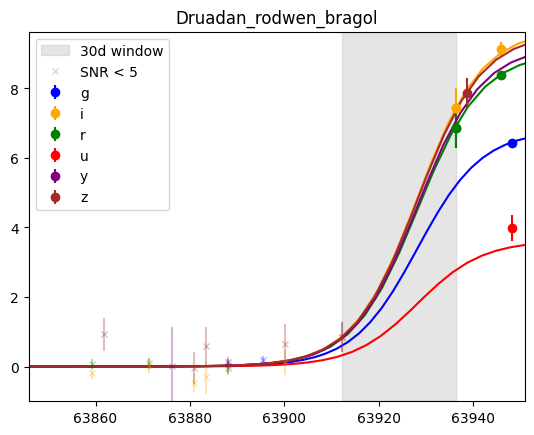

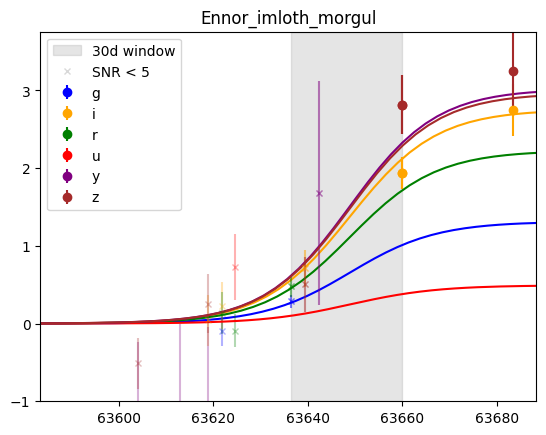

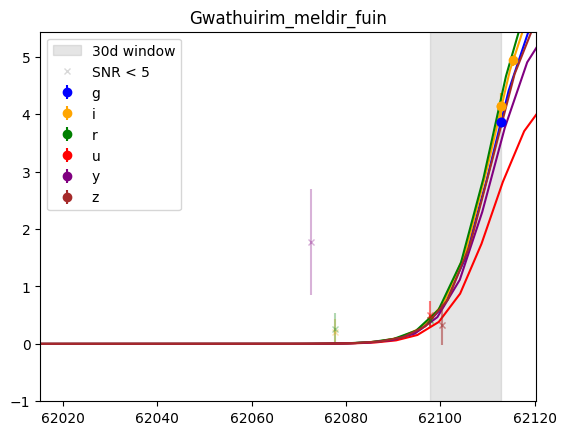

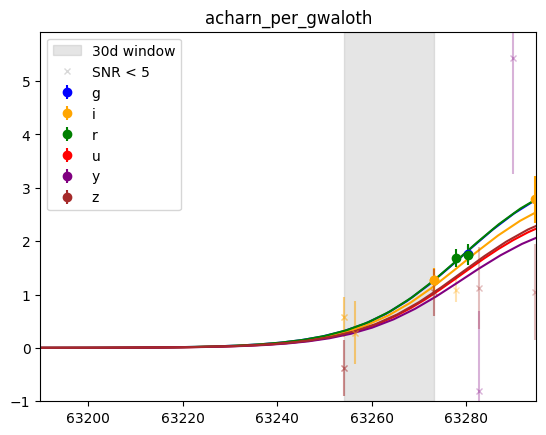

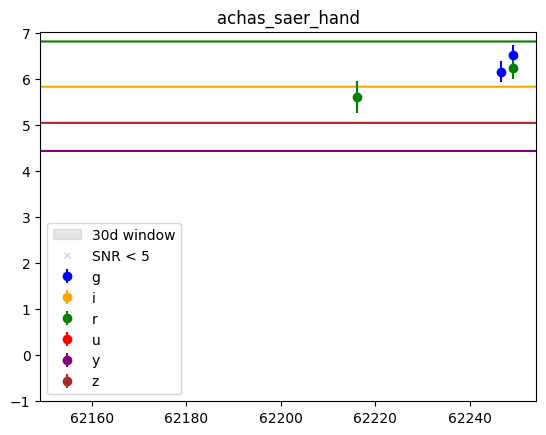

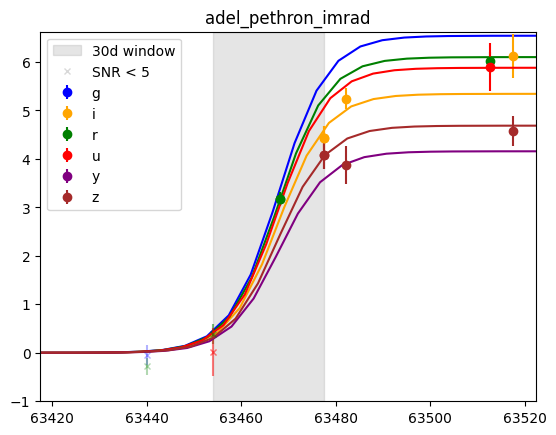

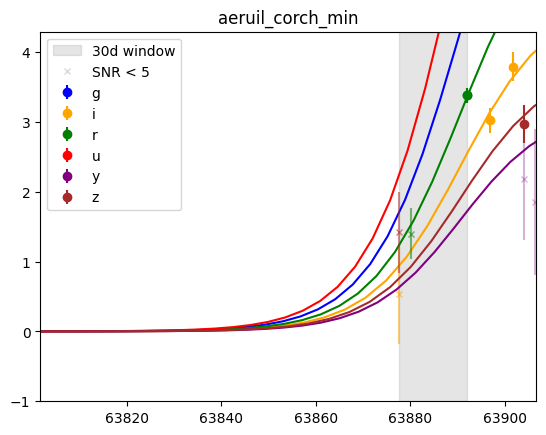

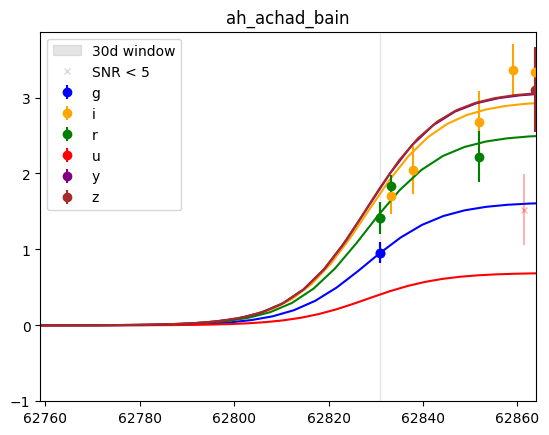

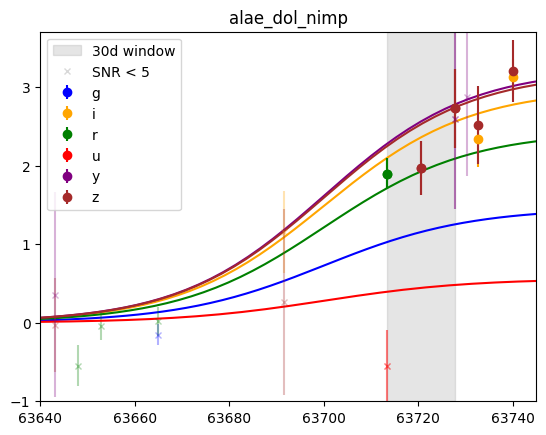

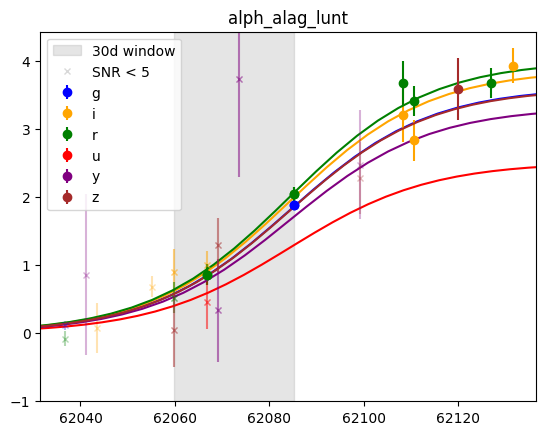

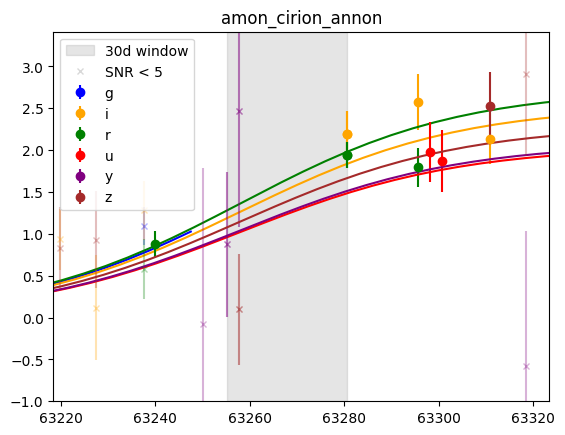

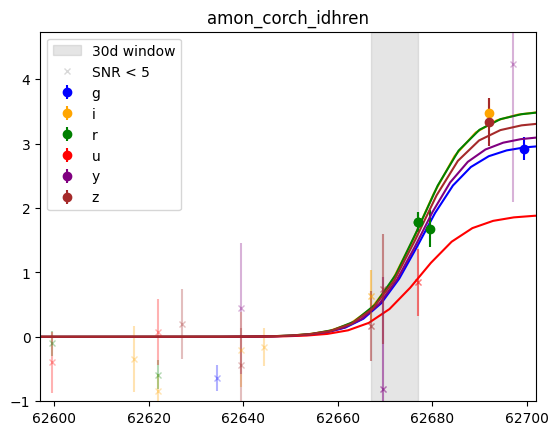

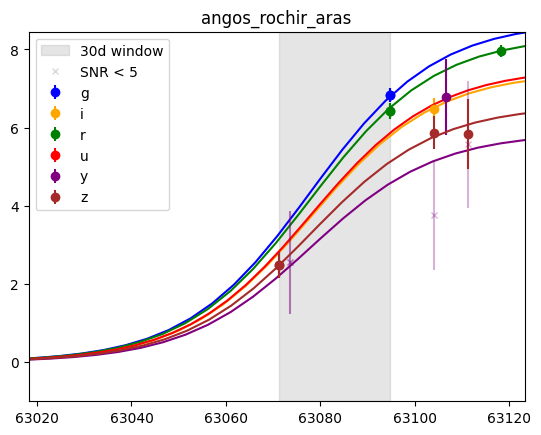

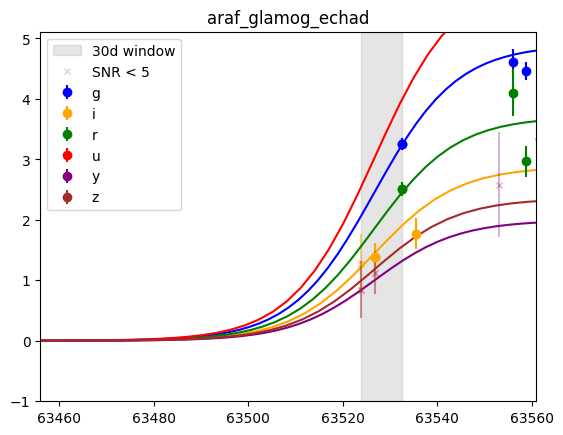

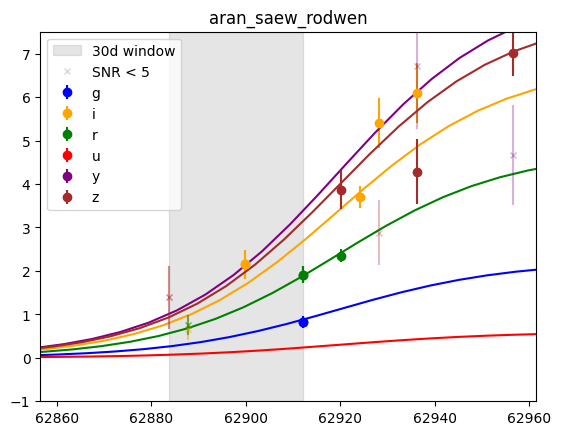

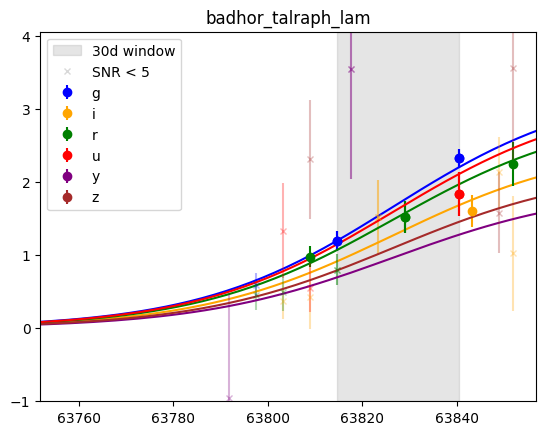

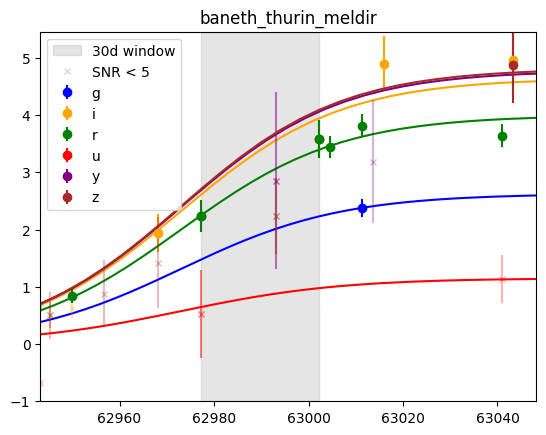

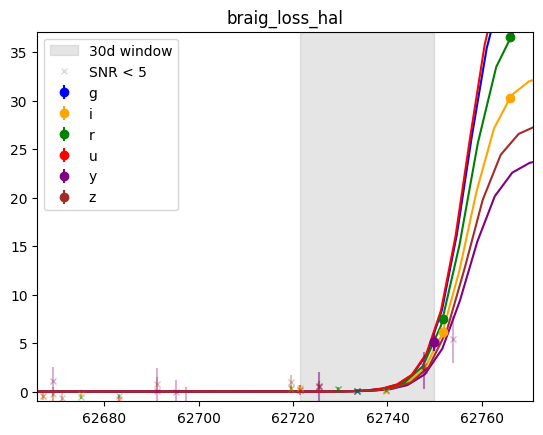

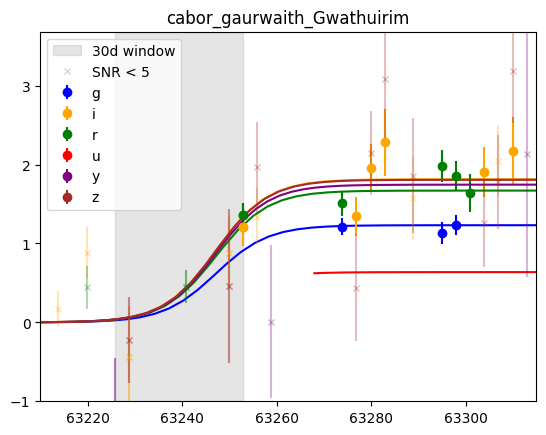

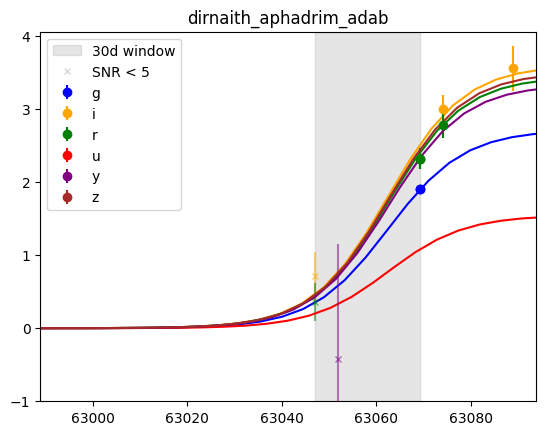

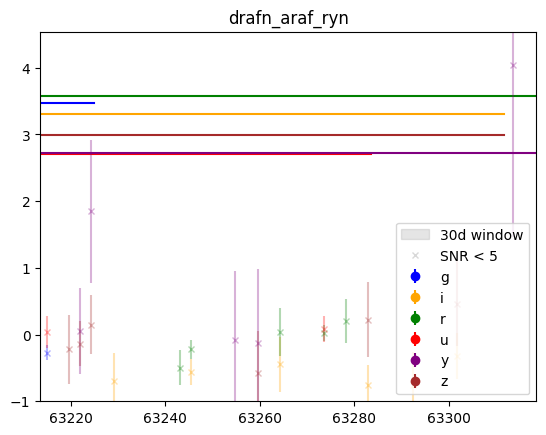

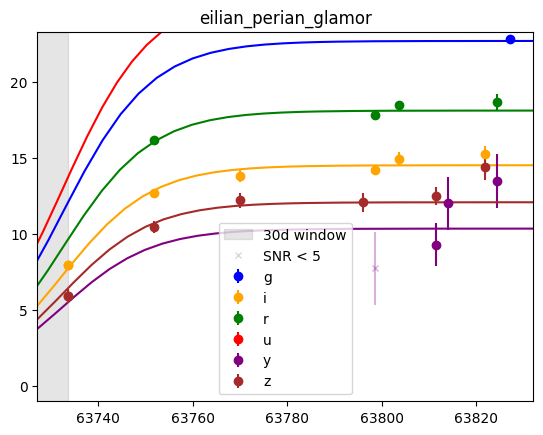

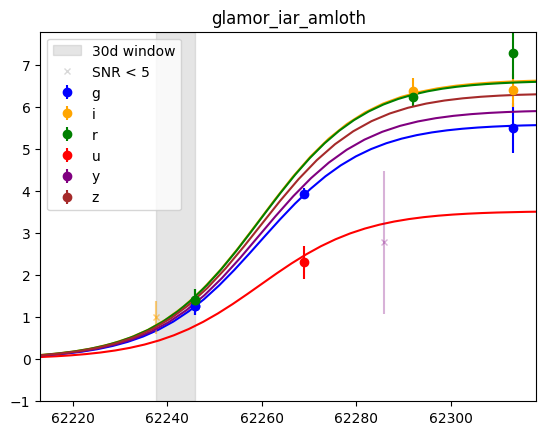

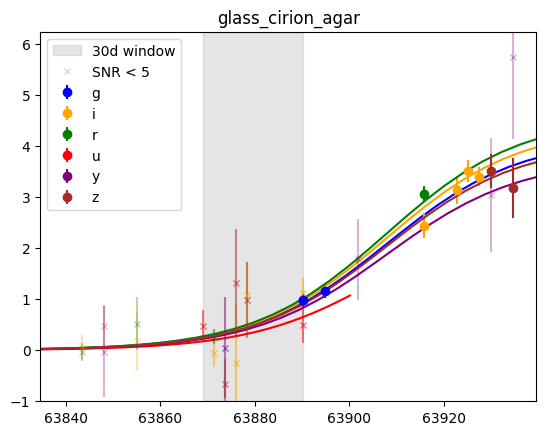

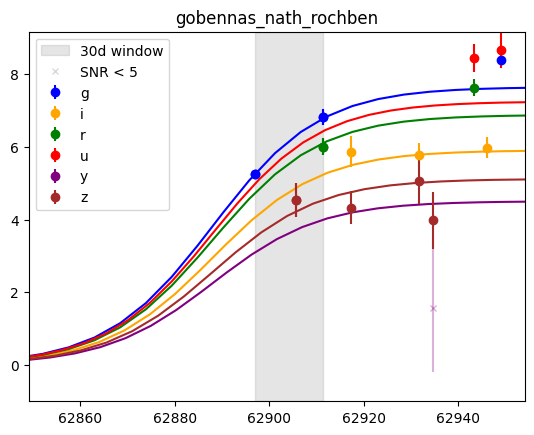

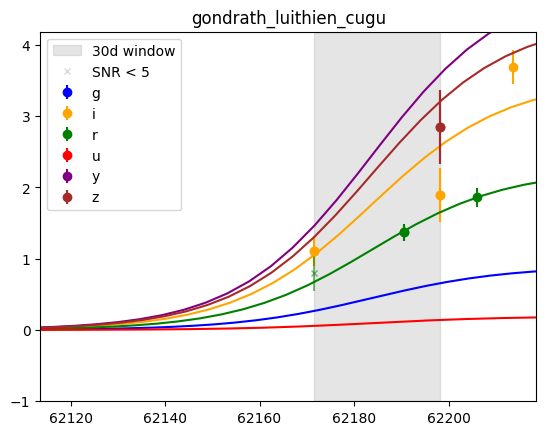

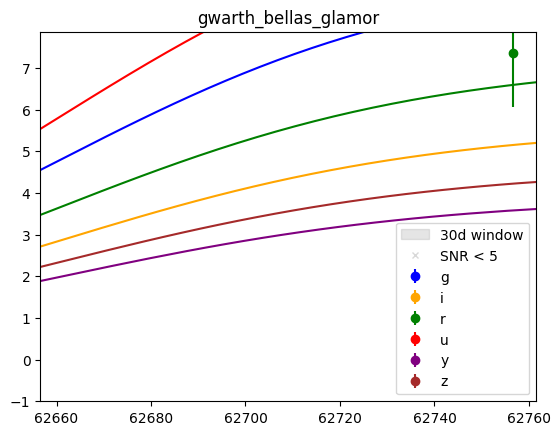

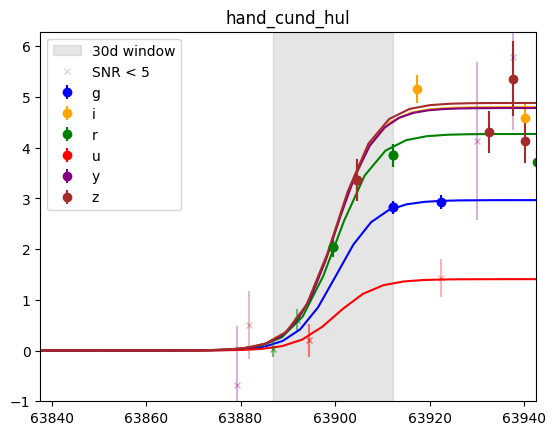

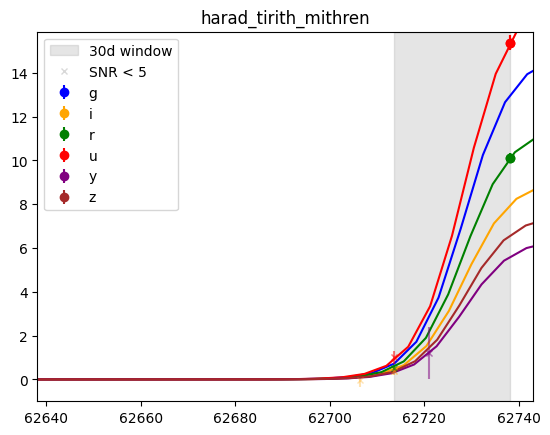

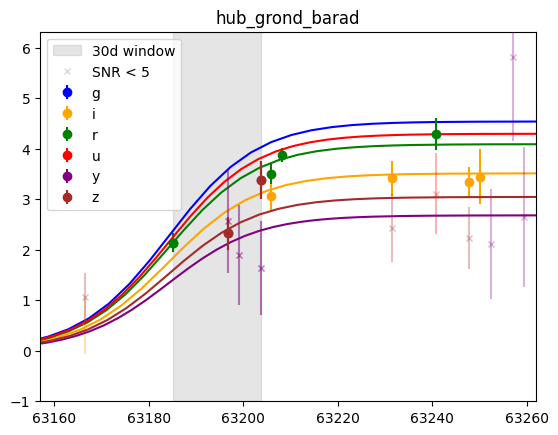

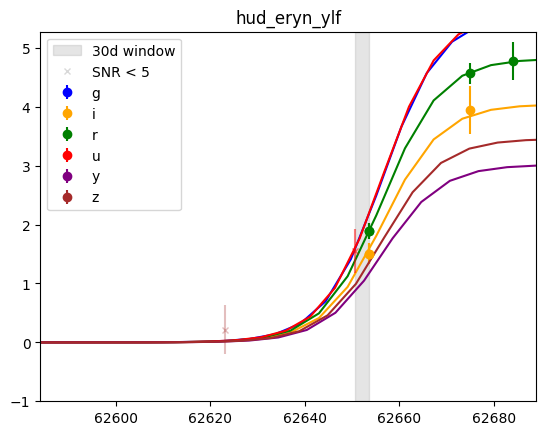

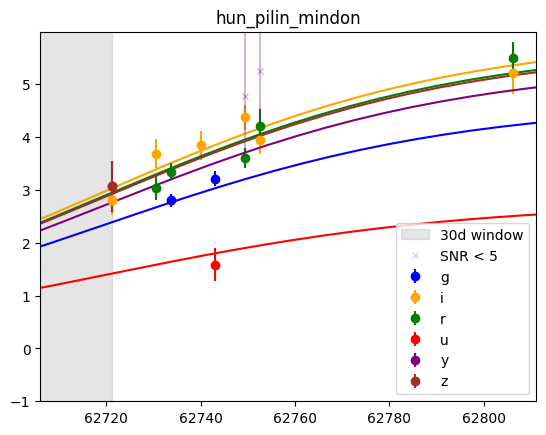

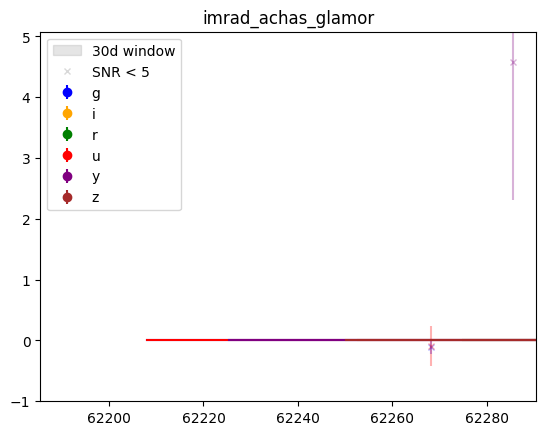

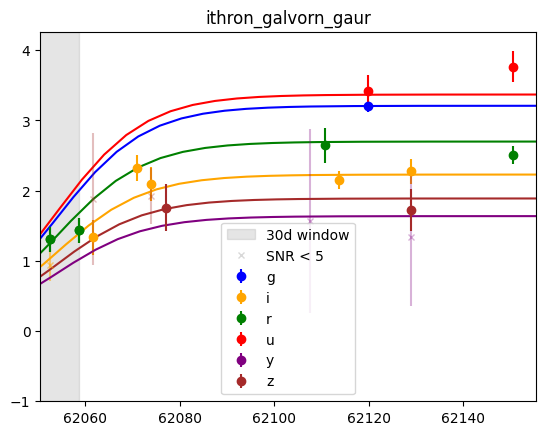

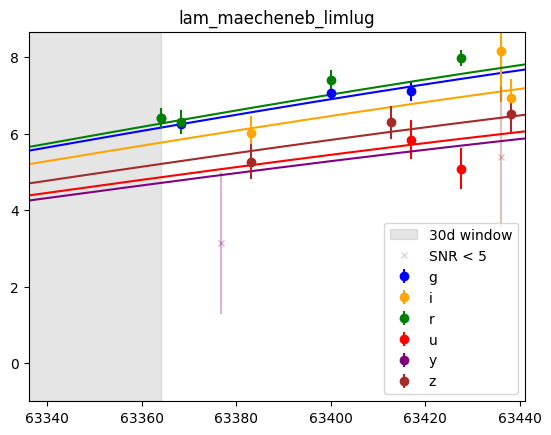

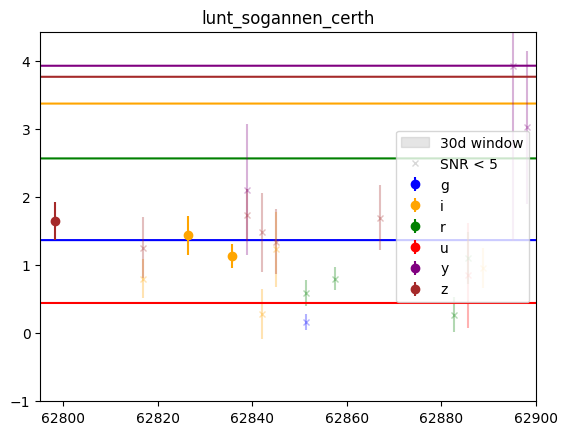

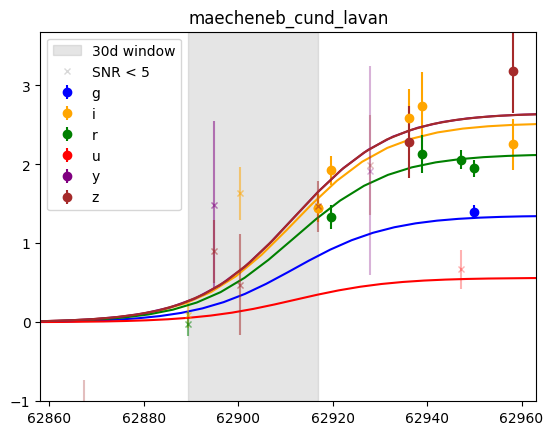

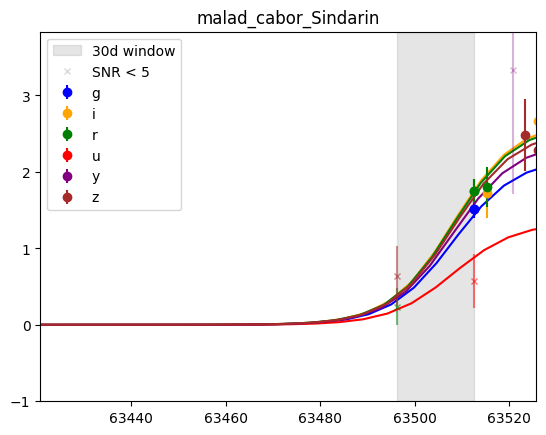

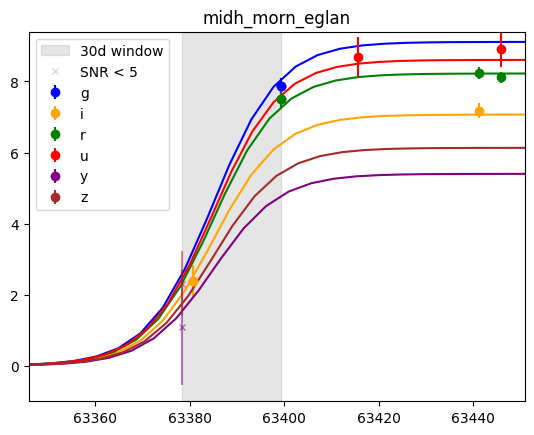

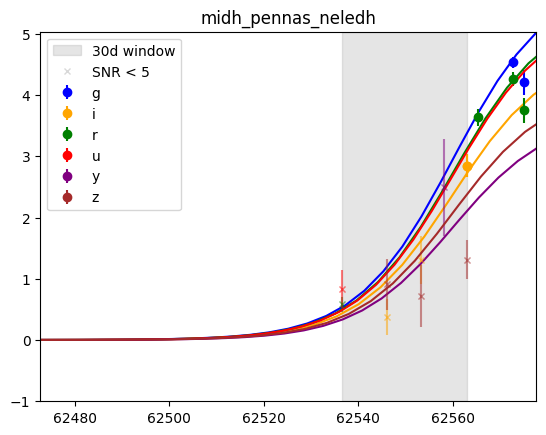

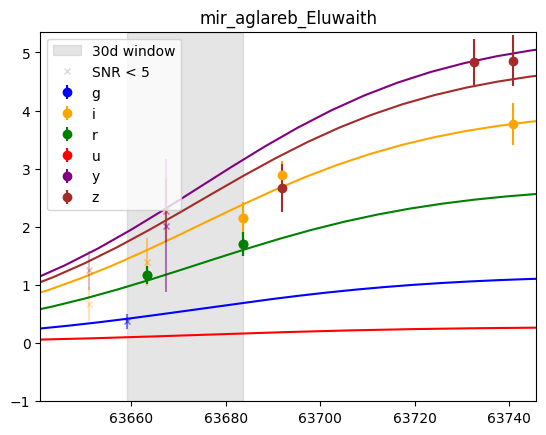

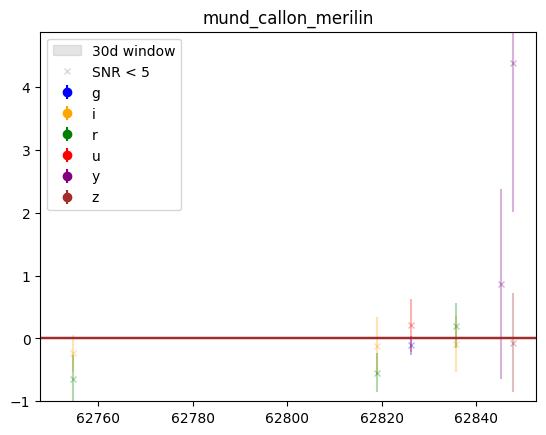

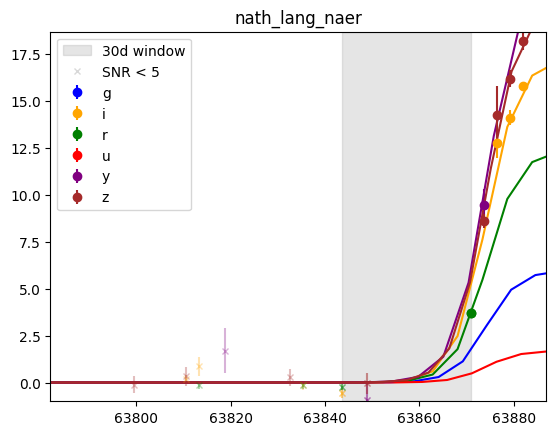

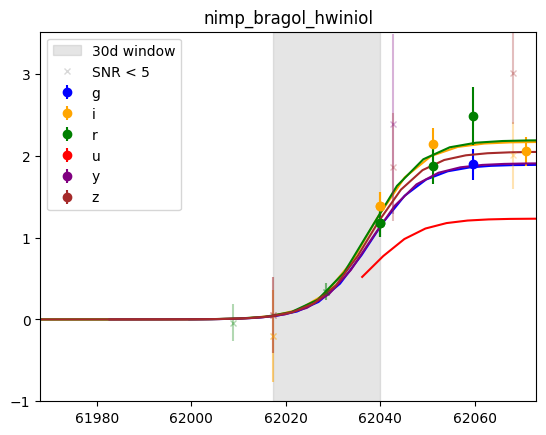

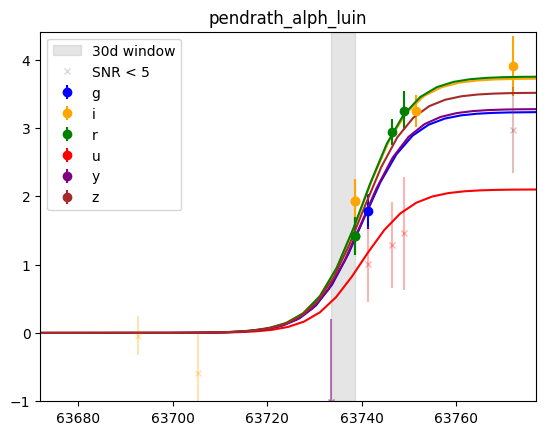

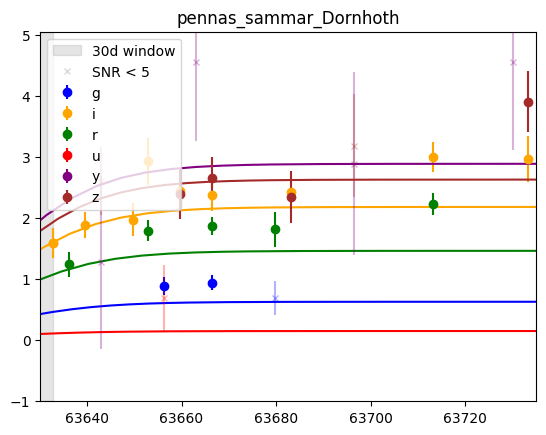

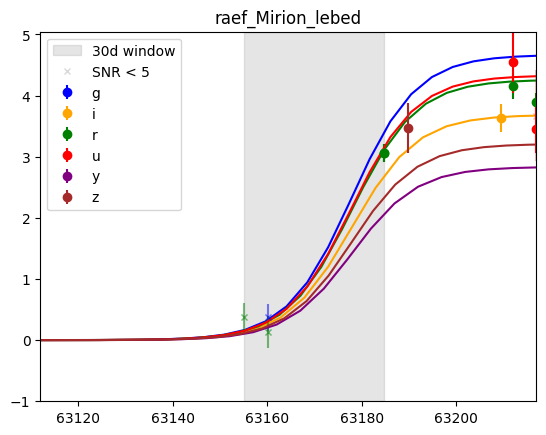

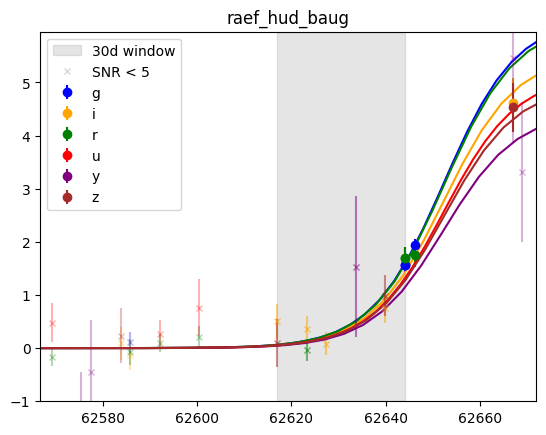

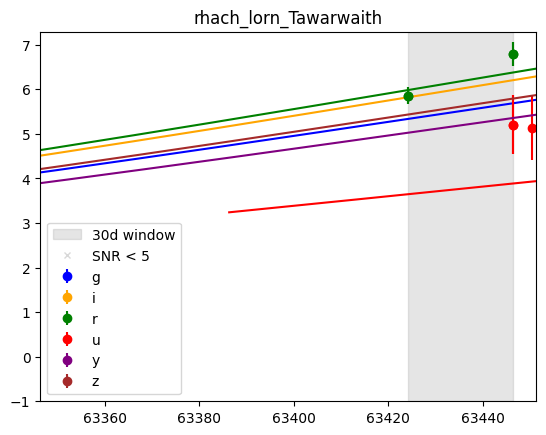

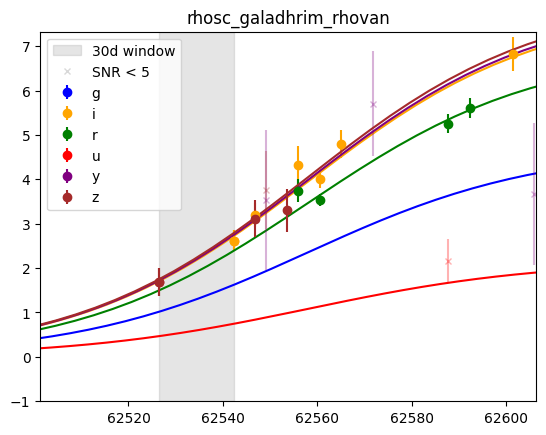

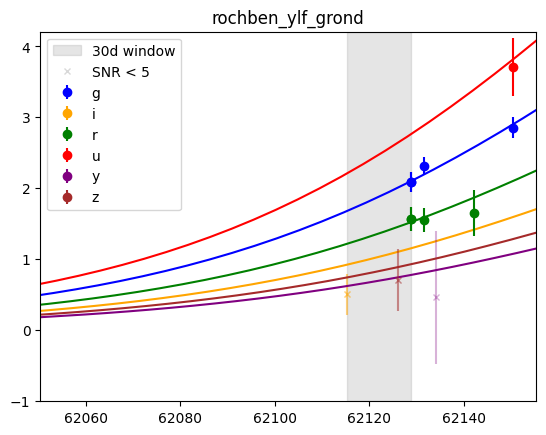

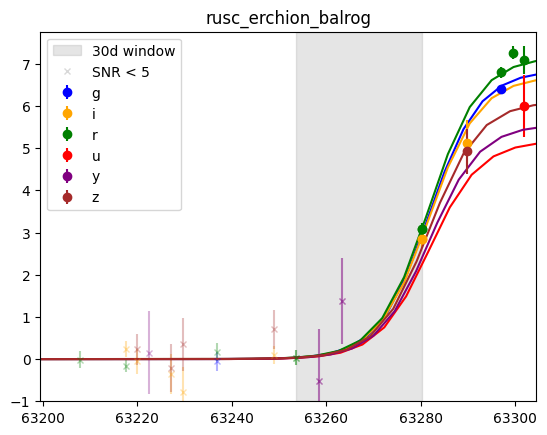

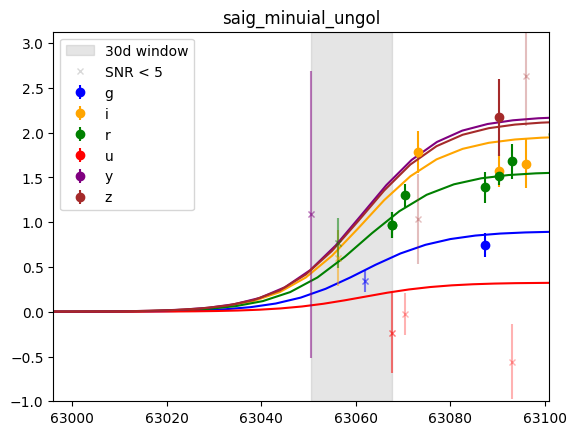

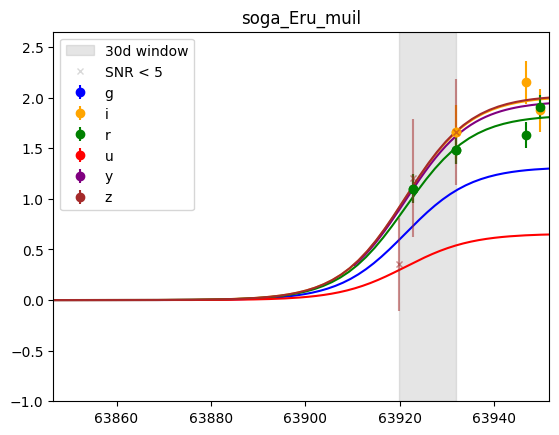

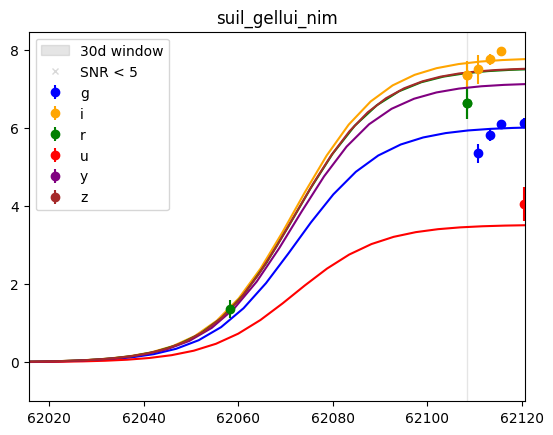

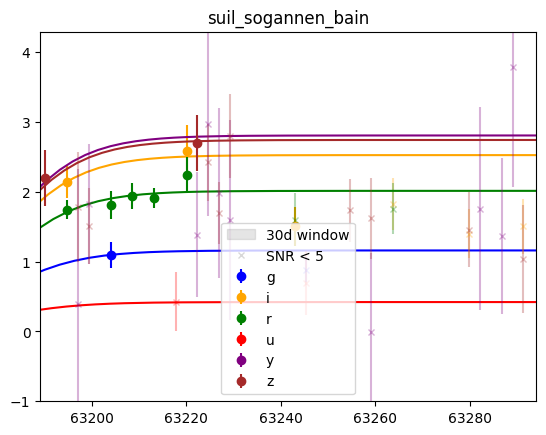

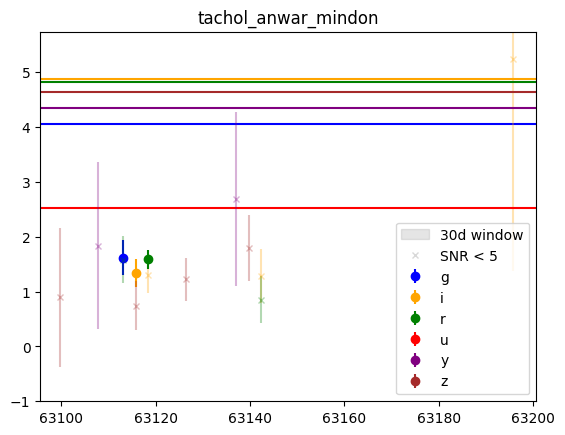

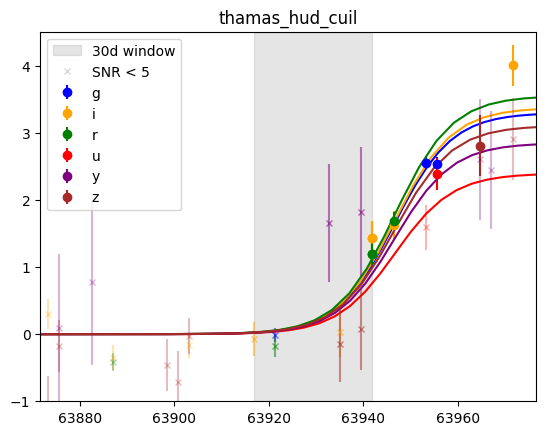

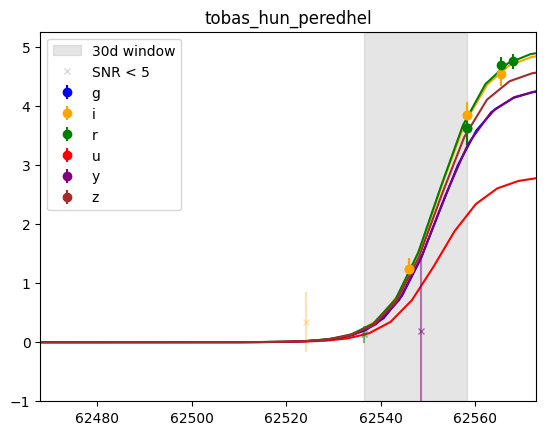

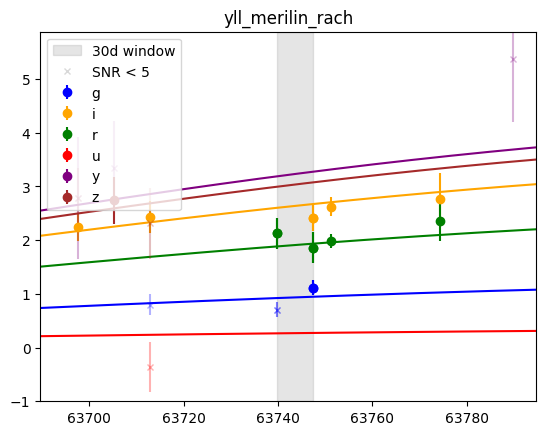

In [15]:

for objid in np.unique(lcs['object_id']):

    lc = lcs[lcs['object_id']==objid].iloc[0]['full_lightcurve']
    feature = features[features['object_id']==objid].iloc[0]

    plt.figure()

    # for idx, band in enumerate(np.unique(lc["filter"])):
    #     mask = (lc["filter"] == band)# & (lc["detection_3SNR"])
    #     time = lc["mjd"][mask]
    #     flux = lc["flux_dered"][mask]
    #     fluerr = lc["flux_err_dered"][mask]

    #     time_smooth = np.linspace(np.min(time)-60, np.max(time)+10, 500)
    #     fit = model.model(time_smooth, band, *feature[names].values)

    #     plt.errorbar(time, flux, yerr=fluerr, fmt="o", label=band, color=colors[idx])
    #     plt.plot(time_smooth, fit, color=colors[idx])

    for idx, band in enumerate(np.unique(lc["filter"])):

      mask_band = (lc["filter"] == band)

      mask_good = mask_band & lc["detection_5SNR"]
      mask_bad  = mask_band & ~lc["detection_5SNR"]

      # --- GOOD points (SNR > 5)
      plt.errorbar(
        lc["mjd"][mask_good],
        lc["flux_dered"][mask_good],
        yerr=lc["flux_err_dered"][mask_good],
        fmt="o",
        color=colors[idx],
        label=band
      )

      # --- BAD points (SNR <= 5)
      plt.errorbar(
        lc["mjd"][mask_bad],
        lc["flux_dered"][mask_bad],
        yerr=lc["flux_err_dered"][mask_bad],
        fmt="x",
        color=colors[idx],
        alpha=0.3,        # more transparent
        markersize=4,     # smaller
      )

      # --- Model
      time = lc["mjd"][mask_band]
      time_smooth = np.linspace(np.min(time)-60, np.max(time)+10, 500)

      fit = model.model(time_smooth, band, *feature[names].values)

      plt.plot(time_smooth, fit, color=colors[idx])

    # Let´s also show the 30-day interval with DR photometry also used for the fit.
    lc_30d = lcs[lcs['object_id']==objid].iloc[0]['lightcurve_preprocessed_30d']
    t_min_30d = lc_30d['mjd'].min()
    t_max_30d = lc_30d['mjd'].max()

    plt.axvspan(t_min_30d, t_max_30d,	color="gray",	alpha=0.2, label="30d window")

    # Plot style
    plt.title(feature['object_id'])
    plt.ylim(-1, np.max(lc['flux_dered'])+0.5)
    peak_time = lc['mjd'].iloc[np.argmax(lc['flux_dered'])]
    plt.xlim(peak_time - 100, peak_time + 5)

    # Add to the legend
    plt.plot([], [], "x",	color="gray",	alpha=0.3, markersize=4, label="SNR < 5")

    plt.legend()




In [ ]:
['Druadan_rodwen_bragol' 'Ennor_imloth_morgul' 'Eru_saelor_tegilbor'
 'Gwathuirim_meldir_fuin' 'Sindarin_araf_pilin' 'ablad_vin_faen'
 'acharn_per_gwaloth' 'achas_saer_hand' 'adel_pethron_imrad'
 'aeruil_corch_min' 'ah_achad_bain' 'alae_dol_nimp' 'alph_alag_lunt'
 'amon_cirion_annon' 'amon_corch_idhren' 'amon_imloth_luin'
 'angos_rochir_aras' 'araf_glamog_echad' 'aran_saew_rodwen'
 'badhor_talraph_lam' 'baneth_thurin_meldir' 'braig_loss_hal'
 'cabor_gaurwaith_Gwathuirim' 'dannas_glandagol_maethor'
 'dirnaith_aphadrim_adab' 'drafn_araf_ryn' 'eilian_perian_glamor'
 'glamor_hul_firiel' 'glamor_iar_amloth' 'glass_cirion_agar'
 'gobennas_nath_rochben' 'gondrath_luithien_cugu' 'gwarth_bellas_glamor'
 'hand_cund_hul' 'harad_tirith_mithren' 'heledir_idhren_melethril'
 'hub_grond_barad' 'hud_bregedur_rist' 'hud_eryn_ylf' 'hun_pilin_mindon'
 'imrad_achas_glamor' 'ithron_galvorn_gaur' 'lachenn_badhor_gwend'
 'lam_maecheneb_limlug' 'lin_graw_hend' 'lunt_sogannen_certh'
 'maecheneb_cund_lavan' 'malad_cabor_Sindarin' 'midh_morn_eglan'
 'midh_pennas_neledh' 'mir_aglareb_Eluwaith' 'mund_callon_merilin'
 'mund_galas_rust' 'nath_lang_naer' 'neledh_gwend_naer'
 'nimp_bragol_hwiniol' 'pendrath_alph_luin' 'pennas_lunt_tinnu'
 'pennas_sammar_Dornhoth' 'pilin_lebenedh_cund' 'rach_lass_tathar'
 'raef_Mirion_lebed' 'raef_hud_baug' 'rhach_lorn_Tawarwaith'
 'rhosc_galadhrim_rhovan' 'rochben_gwaloth_melethron' 'rochben_ylf_grond'
 'rusc_erchion_balrog' 'saig_minuial_ungol' 'soga_Eru_muil'
 'suil_gellui_nim' 'suil_sogannen_bain' 'tachol_anwar_mindon'
 'talraph_myril_aras' 'thamas_hud_cuil' 'thurin_aegas_bregedur'
 'tobas_hun_peredhel' 'yll_merilin_rach']



['Druadan_rodwen_bragol' 'Ennor_imloth_morgul' 'Eru_saelor_tegilbor'
 'Gwathuirim_meldir_fuin' 'Sindarin_araf_pilin' 'ablad_vin_faen'
 'acharn_per_gwaloth' 'achas_saer_hand' 'adel_pethron_imrad'
 'aeruil_corch_min' 'ah_achad_bain' 'alae_dol_nimp' 'alph_alag_lunt'
 'amon_cirion_annon' 'amon_corch_idhren' 'amon_imloth_luin'
 'angos_rochir_aras' 'araf_glamog_echad' 'aran_saew_rodwen'
 'badhor_talraph_lam' 'baneth_thurin_meldir' 'braig_loss_hal'
 'cabor_gaurwaith_Gwathuirim' 'dannas_glandagol_maethor'
 'dirnaith_aphadrim_adab' 'drafn_araf_ryn' 'eilian_perian_glamor'
 'glamor_hul_firiel' 'glamor_iar_amloth' 'glass_cirion_agar'
 'gobennas_nath_rochben' 'gondrath_luithien_cugu' 'gwarth_bellas_glamor'
 'hand_cund_hul' 'harad_tirith_mithren' 'heledir_idhren_melethril'
 'hub_grond_barad' 'hud_bregedur_rist' 'hud_eryn_ylf' 'hun_pilin_mindon'
 'imrad_achas_glamor' 'ithron_galvorn_gaur' 'lachenn_badhor_gwend'
 'lam_maecheneb_limlug' 'lin_graw_hend' 'lunt_sogannen_certh'
 'maecheneb_cund_lavan' 'mal

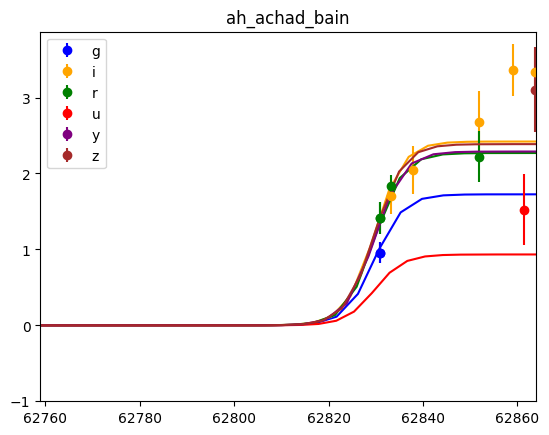

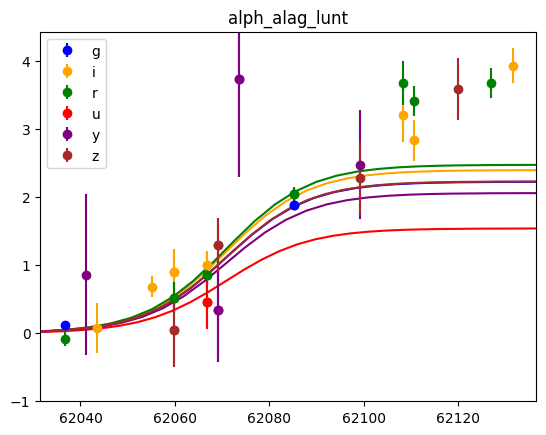

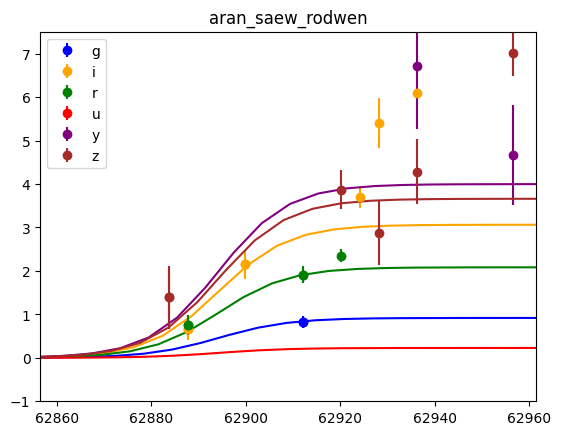

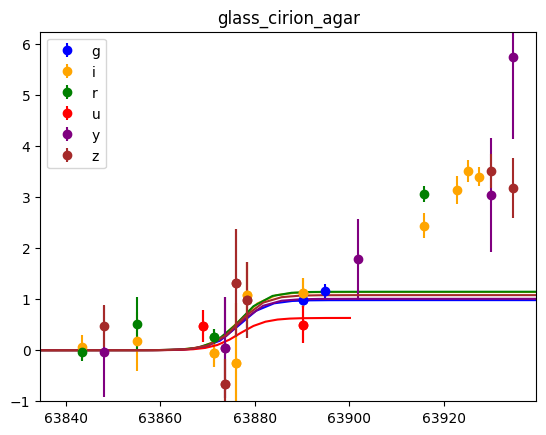

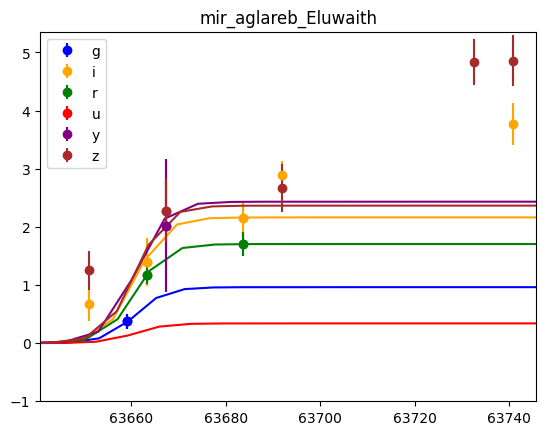

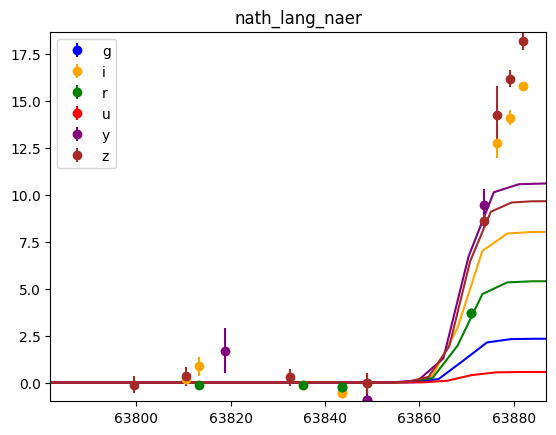

In [ ]:
buggy = ["ah_achad_bain", "alph_alag_lunt", "aran_saew_rodwen",
         "glass_cirion_agar",
         "mir_aglareb_Eluwaith", "nath_lang_naer"]

for objid in buggy:

    lc = lcs[lcs['object_id']==objid].iloc[0]['full_lightcurve']
    feature = features[features['object_id']==objid].iloc[0]

    plt.figure()
    for idx, band in enumerate(np.unique(lc["filter"])):
        mask = (lc["filter"] == band)# & (lc["detection_3SNR"])
        time = lc["mjd"][mask]
        flux = lc["flux_dered"][mask]
        fluerr = lc["flux_err_dered"][mask]

        time_smooth = np.linspace(np.min(time)-60, np.max(time)+10, 500)
        fit = model.model(time_smooth, band, *feature[names].values)

        plt.errorbar(time, flux, yerr=fluerr, fmt="o", label=band, color=colors[idx])
        plt.plot(time_smooth, fit, color=colors[idx])
    plt.title(feature['object_id'])
    plt.ylim(-1, np.max(lc['flux_dered'])+0.5)
    peak_time = lc['mjd'].iloc[np.argmax(lc['flux_dered'])]
    plt.xlim(peak_time - 100, peak_time + 5)
    plt.legend()

